In [97]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import seaborn as sns
import math
import copy

# Set up device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'Device name: {torch.cuda.get_device_name(0)}')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 7)

Using device: cuda
Device name: NVIDIA GeForce RTX 4080 Laptop GPU


In [98]:
# Load the pre-processed data
train_df = pd.read_csv('data/processed/train_FD001_processed.csv')
test_df = pd.read_csv('data/processed/test_FD001_processed.csv')

print("--- Initial Data Shapes ---")
print(f"Training data: {train_df.shape}")
print(f"Test data:     {test_df.shape}")
print("\n--- Training Data Head ---")
print(train_df.head())

--- Initial Data Shapes ---
Training data: (20631, 27)
Test data:     (13096, 27)

--- Training Data Head ---
   engine  cycle  setting1  setting2  setting3  Fan Inlet Temperature (°K)  \
0       1      1   -0.0007   -0.0004     100.0                      288.15   
1       1      2    0.0019   -0.0003     100.0                      288.15   
2       1      3   -0.0043    0.0003     100.0                      288.15   
3       1      4    0.0007    0.0000     100.0                      288.15   
4       1      5   -0.0019   -0.0002     100.0                      288.15   

   LPC Outlet Temperature (°K)  HPC Outlet Temperature (°K)  \
0                   356.566667                   883.166667   
1                   356.750000                   884.344444   
2                   356.861111                   882.216667   
3                   356.861111                   879.327778   
4                   356.872222                   879.361111   

   LPT Outlet Temperature (°K)  Fan Inlet 

In [99]:
# --- Feature Engineering: Rolling Statistics ---
# Define the sensors to engineer features for
sensor_cols = [col for col in train_df.columns if col.startswith('sensor')]
window_size = 5 # A small window to capture recent trends

print(f"Creating rolling window features with window size {window_size}...")

# Create features for the training set
for sensor in sensor_cols:
    train_df[f'{sensor}_rolling_mean'] = train_df.groupby('engine')[sensor].transform(
        lambda x: x.rolling(window_size, min_periods=1).mean()
    )
    train_df[f'{sensor}_rolling_std'] = train_df.groupby('engine')[sensor].transform(
        lambda x: x.rolling(window_size, min_periods=1).std()
    )

# Create features for the test set
for sensor in sensor_cols:
    test_df[f'{sensor}_rolling_mean'] = test_df.groupby('engine')[sensor].transform(
        lambda x: x.rolling(window_size, min_periods=1).mean()
    )
    test_df[f'{sensor}_rolling_std'] = test_df.groupby('engine')[sensor].transform(
        lambda x: x.rolling(window_size, min_periods=1).std()
    )

# Fill any NaNs created by the rolling std on the first element
train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

print("\n--- Data Shapes After Feature Engineering ---")
print(f"Training data: {train_df.shape}")
print(f"Test data:     {test_df.shape}")

Creating rolling window features with window size 5...

--- Data Shapes After Feature Engineering ---
Training data: (20631, 27)
Test data:     (13096, 27)


In [100]:
# Split training data into a training subset and a validation set by engine ID
np.random.seed(42)
all_engine_ids = train_df['engine'].unique()
np.random.shuffle(all_engine_ids)
split_percentage = 0.8
split_point = int(len(all_engine_ids) * split_percentage)

train_subset_ids = all_engine_ids[:split_point]
validation_ids = all_engine_ids[split_point:]

train_subset_df = train_df[train_df['engine'].isin(train_subset_ids)]
val_subset_df = train_df[train_df['engine'].isin(validation_ids)]

# Define feature columns, now including our engineered features
feature_cols = [col for col in train_df.columns if col not in ['engine', 'cycle', 'RUL']]

# Initialize and fit the scaler ONLY on the training subset
scaler = StandardScaler()
scaler.fit(train_subset_df[feature_cols])

# Transform all data sets
train_subset_df[feature_cols] = scaler.transform(train_subset_df[feature_cols])
val_subset_df[feature_cols] = scaler.transform(val_subset_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print(f"Total number of features: {len(feature_cols)}")

Total number of features: 24


/tmp/ipykernel_72671/193676580.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_subset_df[feature_cols] = scaler.transform(train_subset_df[feature_cols])
/tmp/ipykernel_72671/193676580.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_subset_df[feature_cols] = scaler.transform(val_subset_df[feature_cols])


In [101]:
LOOKBACK = 30  # Sequence length, as in your original code

def create_sliding_windows(df, lookback, features):
    X, y = [], []
    for engine_id in df["engine"].unique():
        engine_data = df[df["engine"] == engine_id]
        for i in range(len(engine_data) - lookback + 1):
            window = engine_data.iloc[i:i + lookback][features].values
            X.append(window)
            y.append(engine_data.iloc[i + lookback - 1]["RUL"])
    return np.array(X), np.array(y).reshape(-1, 1)

def get_last_window_per_engine(df, lookback, features):
    X_test, y_test = [], []
    for engine_id in df["engine"].unique():
        engine_data = df[df["engine"] == engine_id]
        # Ensure we have enough data for a full window
        if len(engine_data) >= lookback:
            window = engine_data.iloc[-lookback:][features].values
            X_test.append(window)
            y_test.append(engine_data.iloc[-1]["RUL"])
    return np.array(X_test), np.array(y_test).reshape(-1, 1)

# Create the datasets
X_train_np, y_train_np = create_sliding_windows(train_subset_df, LOOKBACK, feature_cols)

from sklearn.utils import resample

def rebalance_by_rul_bins(X, y, bin_width=20, target_per_bin=2000):
    X_balanced = []
    y_balanced = []

    bins = np.arange(0, 400, bin_width)
    bin_ids = np.digitize(y.flatten(), bins)

    for b in range(1, len(bins)):
        idx = np.where(bin_ids == b)[0]
        if len(idx) == 0:
            continue

        # Undersample if too many, oversample if too few
        if len(idx) > target_per_bin:
            idx_balanced = resample(idx, replace=False, n_samples=target_per_bin, random_state=42)
        else:
            idx_balanced = resample(idx, replace=True,  n_samples=target_per_bin, random_state=42)

        X_balanced.append(X[idx_balanced])
        y_balanced.append(y[idx_balanced])

    return np.concatenate(X_balanced, axis=0), np.concatenate(y_balanced, axis=0)

print("Rebalancing training windows...")
X_train_np_bal, y_train_np_bal = rebalance_by_rul_bins(X_train_np, y_train_np, bin_width=20, target_per_bin=2000)

print("Before:", X_train_np.shape, "After:", X_train_np_bal.shape)


X_val_np, y_val_np = create_sliding_windows(val_subset_df, LOOKBACK, feature_cols)
X_test_np, y_test_np = get_last_window_per_engine(test_df, LOOKBACK, feature_cols)

print("--- Data Window Shapes ---")
print(f"X_train: {X_train_np.shape}, y_train: {y_train_np.shape}")
print(f"X_val:   {X_val_np.shape}, y_val:   {y_val_np.shape}")
print(f"X_test:  {X_test_np.shape}, y_test:  {y_test_np.shape}")

Rebalancing training windows...
Before: (14020, 30, 24) After: (34000, 30, 24)
--- Data Window Shapes ---
X_train: (14020, 30, 24), y_train: (14020, 1)
X_val:   (3711, 30, 24), y_val:   (3711, 1)
X_test:  (100, 30, 24), y_test:  (100, 1)


In [102]:
# Convert numpy arrays to PyTorch tensors
X_train = torch.from_numpy(X_train_np_bal).float()
y_train = torch.from_numpy(y_train_np_bal).float()
X_val = torch.from_numpy(X_val_np).float()
y_val = torch.from_numpy(y_val_np).float()
X_test = torch.from_numpy(X_test_np).float()
y_test = torch.from_numpy(y_test_np).float()

# Create TensorDatasets and DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, shuffle=False, batch_size=batch_size)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

print(f"Number of training batches: {len(train_loader)}")

Number of training batches: 532


In [103]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class CNNTransformerRUL(nn.Module):
    def __init__(self, input_dim, d_model, nhead, d_hid, nlayers, dropout=0.5):
        super(CNNTransformerRUL, self).__init__()

        # 1. CNN Feature Extractor
        self.cnn_extractor = nn.Sequential(
            nn.Conv1d(input_dim, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # 2. Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # 3. Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, d_hid, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, nlayers)

        # 4. Regression Head for final prediction
        self.regression_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, src):
        # src shape: [batch_size, seq_len, features] -> CNN expects: [batch_size, features, seq_len]
        src = src.permute(0, 2, 1)
        src = self.cnn_extractor(src)

        # Permute back for Transformer: [batch_size, seq_len, features]
        src = src.permute(0, 2, 1)

        # Positional Encoding and Transformer
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)

        # Use the output of the last time step for the RUL prediction
        seq_rep = torch.mean(output, dim=1)
        output = self.regression_head(seq_rep)
        return output

# --- Model Hyperparameters ---
input_dim = X_train.shape[2]
d_model = 128
nhead = 8
d_hid = 256
nlayers = 4
dropout = 0.2

model = CNNTransformerRUL(input_dim, d_model, nhead, d_hid, nlayers, dropout).to(device)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

CNNTransformerRUL(
  (cnn_extractor): Sequential(
    (0): Conv1d(24, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inp

In [104]:
# --- Asymmetric Loss Function ---
# Penalizes over-predictions (y_pred > y_true) more heavily
def asymmetric_mse_loss(y_pred, y_true, over_prediction_penalty=2.0):
    error = y_pred - y_true
    loss = torch.mean(torch.where(error > 0, error**2 * over_prediction_penalty, error**2))
    return loss

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.2, patience=5)

# --- Training Loop ---
epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = None
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            output = model(batch_X)
            # Use standard MSE for validation loss for consistent comparison
            val_loss = nn.functional.mse_loss(output, batch_y)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)
    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print("Validation loss improved, saving model weights.")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break

# Load the best performing model weights for final evaluation
if best_model_weights:
    model.load_state_dict(best_model_weights)

Epoch 001 | Train Loss: 33896.8438 | Val Loss: 9081.3242
Validation loss improved, saving model weights.
Epoch 002 | Train Loss: 23027.2742 | Val Loss: 3548.5977
Validation loss improved, saving model weights.
Epoch 003 | Train Loss: 10081.4434 | Val Loss: 2446.8753
Validation loss improved, saving model weights.
Epoch 004 | Train Loss: 3368.2292 | Val Loss: 3517.1767
Epoch 005 | Train Loss: 1558.3432 | Val Loss: 2410.9970
Validation loss improved, saving model weights.
Epoch 006 | Train Loss: 721.1210 | Val Loss: 2703.5288
Epoch 007 | Train Loss: 487.4405 | Val Loss: 2925.1653
Epoch 008 | Train Loss: 384.0338 | Val Loss: 2936.3640
Epoch 009 | Train Loss: 320.9747 | Val Loss: 2839.2610
Epoch 010 | Train Loss: 269.3407 | Val Loss: 2798.9492
Epoch 011 | Train Loss: 237.4486 | Val Loss: 3129.2622
Epoch 012 | Train Loss: 200.8984 | Val Loss: 2898.6028
Epoch 013 | Train Loss: 192.2653 | Val Loss: 2973.6997
Epoch 014 | Train Loss: 186.4547 | Val Loss: 2782.5297
Epoch 015 | Train Loss: 180.36

### Test Set Performance


--- Test Set Performance ---
Test MAE: 25.34
Test RMSE: 36.13



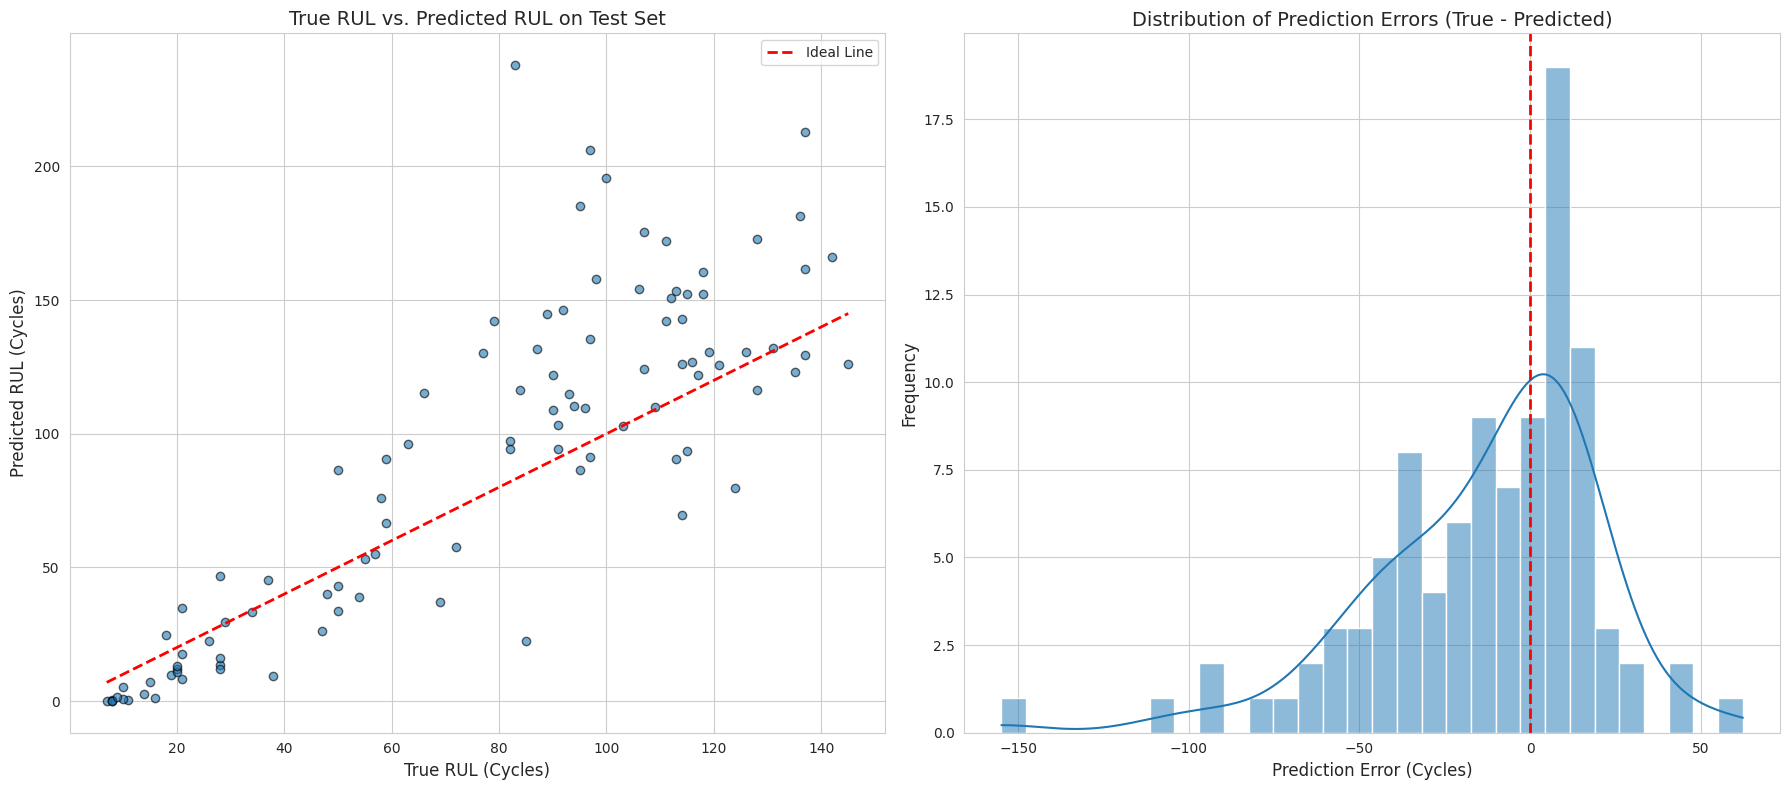

In [105]:
model.eval()
y_pred_list = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_pred_list.append(output.cpu().numpy())

y_pred_test = np.concatenate(y_pred_list, axis=0).flatten()
y_test_np_flat = y_test_np.flatten()

# Calculate final metrics on the test set
mae_test = mean_absolute_error(y_test_np_flat, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_np_flat, y_pred_test))

print("\n--- Test Set Performance ---")
print(f"Test MAE: {mae_test:.2f}")
print(f"Test RMSE: {rmse_test:.2f}\n")

# --- Visualization ---
plt.figure(figsize=(18, 8))

# 1. True RUL vs. Predicted RUL
plt.subplot(1, 2, 1)
plt.scatter(y_test_np_flat, y_pred_test, alpha=0.6, edgecolors='k')
plt.plot([min(y_test_np_flat), max(y_test_np_flat)], [min(y_test_np_flat), max(y_test_np_flat)], color='red', linestyle='--', lw=2, label='Ideal Line')
plt.title('True RUL vs. Predicted RUL on Test Set', fontsize=14)
plt.xlabel('True RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.grid(True)
plt.legend()

# 2. Distribution of Prediction Errors
errors = y_test_np_flat - y_pred_test
plt.subplot(1, 2, 2)
sns.histplot(errors, bins=30, kde=True)
plt.title('Distribution of Prediction Errors (True - Predicted)', fontsize=14)
plt.xlabel('Prediction Error (Cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)

plt.tight_layout()
plt.show()

### Validation Set Performance

In [106]:
model.eval()
y_val_pred_list = []
with torch.no_grad():
    for batch_X, _ in val_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_val_pred_list.append(output.cpu().numpy())
y_val_pred = np.concatenate(y_val_pred_list, axis=0).flatten()
y_val_np_flat = y_val_np.flatten()
mae_val = mean_absolute_error(y_val_np_flat, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_np_flat, y_val_pred))
print("\n--- Validation Set Performance ---")
print(f"Validation MAE: {mae_val:.2f}")
print(f"Validation RMSE: {rmse_val:.2f}\n")


--- Validation Set Performance ---
Validation MAE: 33.78
Validation RMSE: 49.10



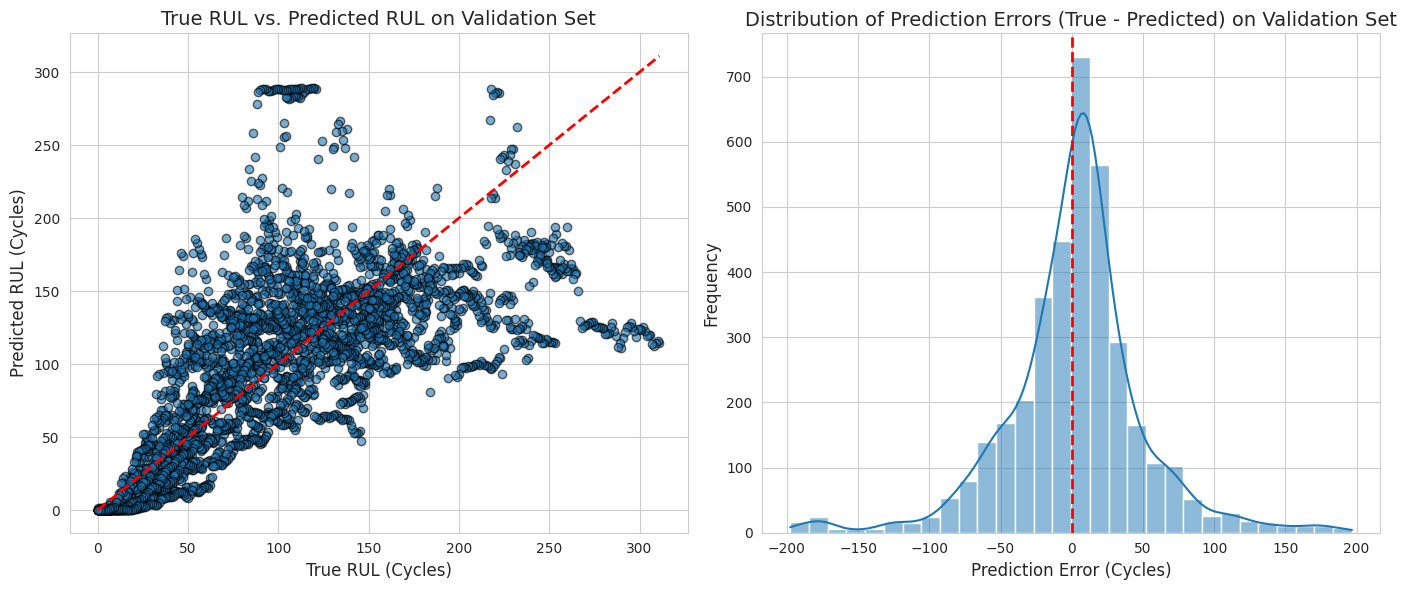

In [107]:
# plot for validation set
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_val_np_flat, y_val_pred, alpha=0.6, edgecolors='k')
plt.plot([min(y_val_np_flat), max(y_val_np_flat)], [min(y_val_np_flat), max(y_val_np_flat)], color='red', linestyle='--', lw=2)
plt.title('True RUL vs. Predicted RUL on Validation Set', fontsize=14)
plt.xlabel('True RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.grid(True)
errors_val = y_val_np_flat - y_val_pred
plt.subplot(1, 2, 2)
sns.histplot(errors_val, bins=30, kde=True)
plt.title('Distribution of Prediction Errors (True - Predicted) on Validation Set', fontsize=14)
plt.xlabel('Prediction Error (Cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# Troubleshooting

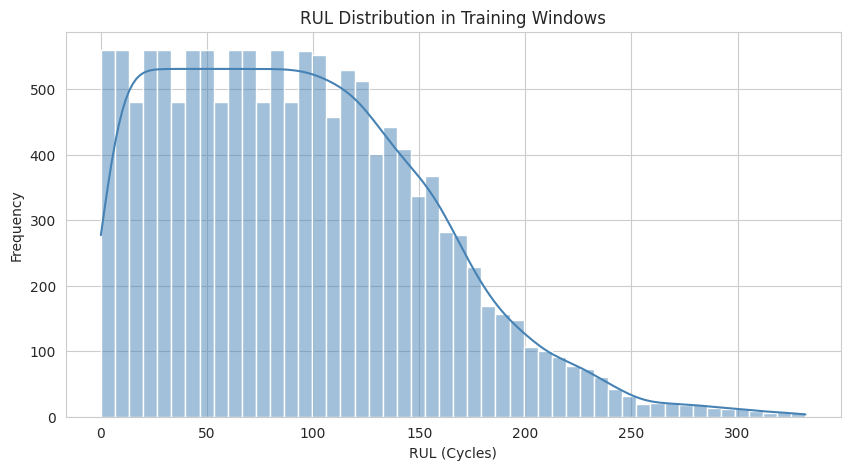

In [108]:
plt.figure(figsize=(10,5))
sns.histplot(y_train_np.flatten(), bins=50, kde=True, color='steelblue')
plt.title("RUL Distribution in Training Windows")
plt.xlabel("RUL (Cycles)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


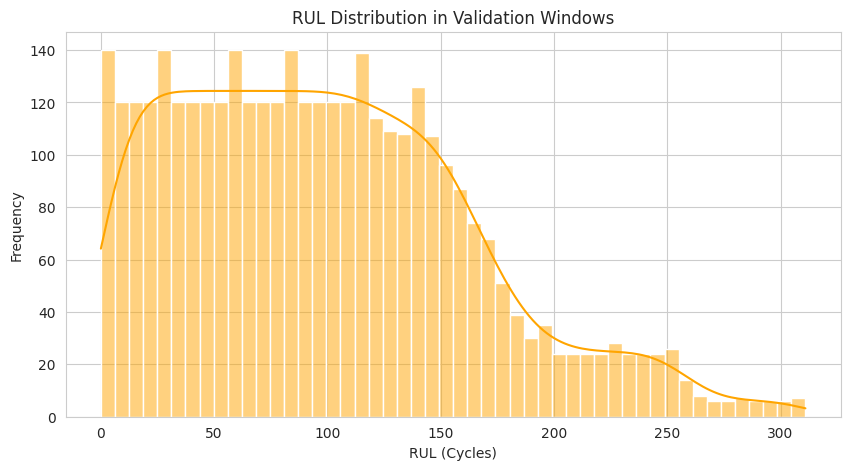

In [109]:
plt.figure(figsize=(10,5))
sns.histplot(y_val_np.flatten(), bins=50, kde=True, color='orange')
plt.title("RUL Distribution in Validation Windows")
plt.xlabel("RUL (Cycles)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


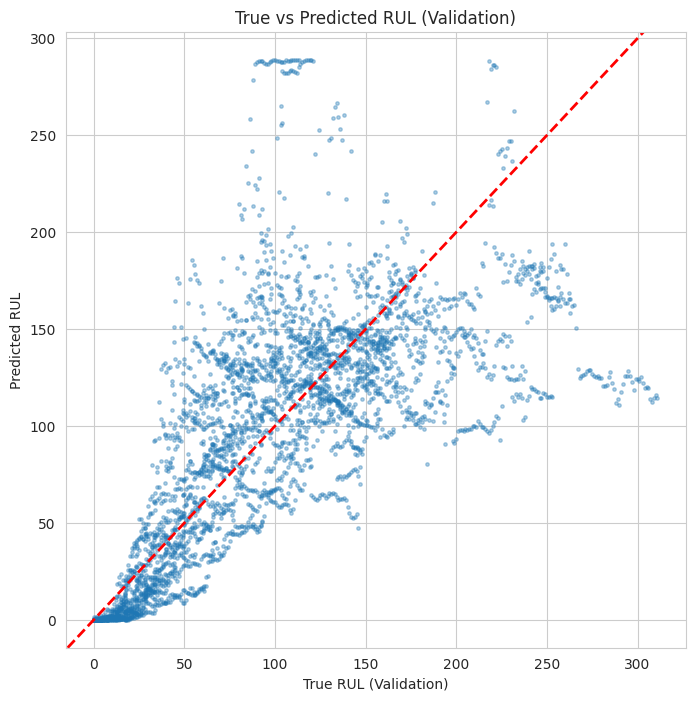

In [110]:
plt.figure(figsize=(8,8))
plt.scatter(y_val_np_flat, y_val_pred, s=6, alpha=0.35)
plt.axline((0,0), slope=1, color='red', linestyle='--', lw=2)
plt.xlabel("True RUL (Validation)")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL (Validation)")
plt.grid(True)
plt.show()

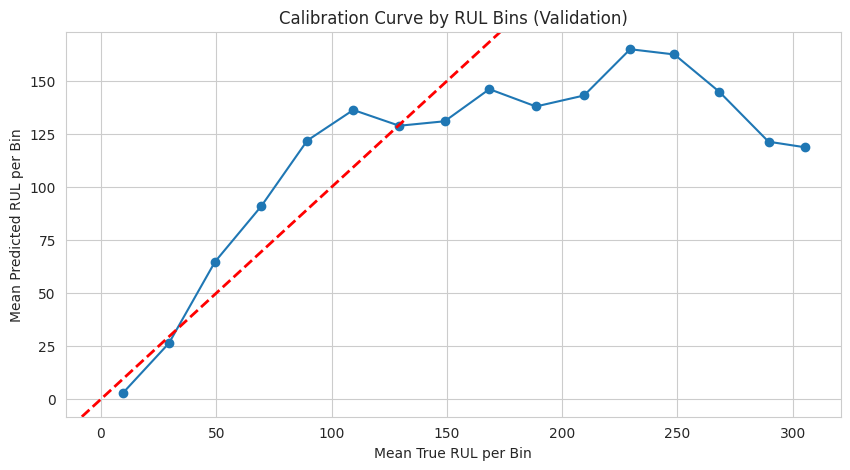

In [111]:
bins = np.arange(0, 330, 20)
bin_ids = np.digitize(y_val_np_flat, bins)

avg_true = []
avg_pred = []
for i in range(1, len(bins)):
    m = bin_ids == i
    if np.any(m):
        avg_true.append(np.mean(y_val_np_flat[m]))
        avg_pred.append(np.mean(y_val_pred[m]))

plt.figure(figsize=(10,5))
plt.plot(avg_true, avg_pred, marker='o')
plt.axline((0,0), slope=1, color='red', linestyle='--', lw=2)
plt.xlabel("Mean True RUL per Bin")
plt.ylabel("Mean Predicted RUL per Bin")
plt.title("Calibration Curve by RUL Bins (Validation)")
plt.grid(True)
plt.show()


In [112]:
mask_hi = y_val_np_flat >= 150
if np.sum(mask_hi) > 5:
    # simple linear fit: predicted = a * true + b
    a_hi, b_hi = np.polyfit(y_val_np_flat[mask_hi], y_val_pred[mask_hi], 1)
    print(f"Slope for True RUL ≥ 150: {a_hi:.3f}  (0 ≈ hard ceiling, 1 ≈ ideal)")
else:
    print("Not enough points ≥150 to estimate slope.")


Slope for True RUL ≥ 150: 0.066  (0 ≈ hard ceiling, 1 ≈ ideal)


In [113]:
print(f"Max predicted RUL on validation: {np.max(y_val_pred):.1f}")
print(f"95th percentile of predictions:  {np.percentile(y_val_pred, 95):.1f}")


Max predicted RUL on validation: 289.0
95th percentile of predictions:  181.6


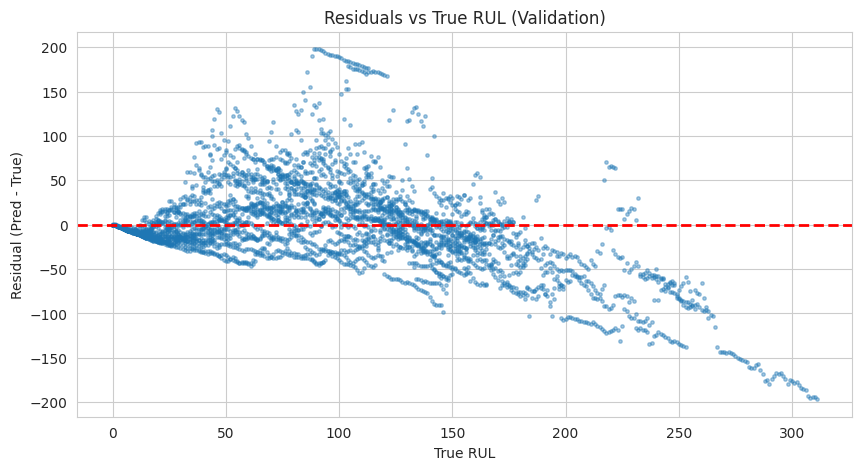

In [114]:
resid = y_val_pred - y_val_np_flat
plt.figure(figsize=(10,5))
plt.scatter(y_val_np_flat, resid, s=6, alpha=0.4)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("True RUL")
plt.ylabel("Residual (Pred - True)")
plt.title("Residuals vs True RUL (Validation)")
plt.grid(True)
plt.show()


In [115]:
over = np.mean(resid > 0)
under = np.mean(resid < 0)
print(f"Over-predictions:  {over*100:.1f}%")
print(f"Under-predictions: {under*100:.1f}%")


Over-predictions:  43.4%
Under-predictions: 56.6%


In [116]:
bands = [(0,50),(50,100),(100,150),(150,200),(200,250),(250,320)]
for lo, hi in bands:
    m = (y_val_np_flat >= lo) & (y_val_np_flat < hi)
    if np.any(m):
        mae = np.mean(np.abs(resid[m]))
        bias = np.mean(resid[m])
        print(f"{lo:3d}-{hi:<3d}: n={np.sum(m):4d} | MAE={mae:6.2f} | Bias={bias:7.2f}")


  0-50 : n=1000 | MAE= 14.78 | Bias=  -1.60
 50-100: n=1000 | MAE= 38.28 | Bias=  25.43
100-150: n= 943 | MAE= 32.48 | Bias=   7.50
150-200: n= 480 | MAE= 32.05 | Bias= -26.94
200-250: n= 200 | MAE= 74.31 | Bias= -68.92
250-320: n=  88 | MAE=129.94 | Bias=-129.94


### Post Training Data

In [117]:
model.eval()
y_val_pred_list = []
with torch.no_grad():
    for batch_X, _ in val_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_val_pred_list.append(output.cpu().numpy())

y_val_pred = np.concatenate(y_val_pred_list, axis=0).flatten()
y_val_np_flat = y_val_np.flatten()


In [118]:
mask_hi = y_val_np_flat >= 150
a_hi, b_hi = np.polyfit(y_val_np_flat[mask_hi], y_val_pred[mask_hi], 1)
print("New slope ≥150:", round(a_hi,3))


New slope ≥150: 0.066


In [119]:
print("Max predicted:", np.max(y_val_pred))
print("95th percentile:", np.percentile(y_val_pred,95))


Max predicted: 288.96692
95th percentile: 181.60638
